In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("enhanced_electric_scooters(final).csv")

print("Initial Shape:", df.shape)
df.head()

Initial Shape: (364, 22)


,scooter_name,brand,variant,ex_showroom_price_inr,battery_capacity_kwh,range_km,top_speed_kmph,charging_time_hrs,motor_power,kerb_weight_kg,...,digital_display,riding_modes,fast_charging,user_rating,num_reviews,url,segment,brand_value,brand_country,brand_model_count
0,TVS iQube,TVS,Bajaj Chetak C2501,115322.0,2.2,94.0,75.0,5.0,4.4,110.0,...,True,True,True,4.4,483.0,https://www.bikedekho.com/tvs/iqube-electric,mid,9,India,5
1,Bajaj Chetak,Bajaj,Bajaj Chetak C2501,107400.0,3.0,127.0,63.0,350.0,NaN,NaN,...,True,True,True,4.6,140.0,https://www.bikedekho.com/bajaj/chetak,mid,8,India,2
2,Ather Rizta,Ather,Bajaj Chetak C2501,75999.0,2.9,123.0,80.0,830.0,4.3,125.0,...,True,True,False,4.6,82.0,https://www.bikedekho.com/ather-energy/rizta,budget,9,India,4
3,Ather 450X,Ather,450X EMI,147999.0,2.9,126.0,90.0,4.3,6.4,108.0,...,True,False,True,4.8,74.0,https://www.bikedekho.com/ather-energy/450x,premium,9,India,4
4,Honda Activa e,Honda,Bajaj Chetak C2501,118147.0,3.0,102.0,80.0,NaN,6.0,118.0,...,True,True,False,4.6,95.0,https://www.bikedekho.com/honda/activa-electric,mid,5,Unknown,3


In [ ]:
df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   scooter_name           364 non-null    object 
 1   brand                  364 non-null    object 
 2   variant                364 non-null    object 
 3   ex_showroom_price_inr  363 non-null    float64
 4   battery_capacity_kwh   305 non-null    float64
 5   range_km               343 non-null    float64
 6   top_speed_kmph         340 non-null    float64
 7   charging_time_hrs      110 non-null    float64
 8   motor_power            274 non-null    float64
 9   kerb_weight_kg         158 non-null    float64
 10  bluetooth              364 non-null    bool   
 11  navigation             364 non-null    bool   
 12  digital_display        364 non-null    bool   
 13  riding_modes           364 non-null    bool   
 14  fast_charging          364 non-null    bool   
 15  user_r

In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['scooter_name', 'brand', 'variant', 'ex_showroom_price_inr',
       'battery_capacity_kwh', 'range_km', 'top_speed_kmph',
       'charging_time_hrs', 'motor_power', 'kerb_weight_kg', 'bluetooth',
       'navigation', 'digital_display', 'riding_modes', 'fast_charging',
       'user_rating', 'num_reviews', 'url', 'segment', 'brand_value',
       'brand_country', 'brand_model_count'],
      dtype='object')

In [ ]:
# Numeric columns → median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns → "Unknown"
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

df.isnull().sum()

,0
scooter_name,0
brand,0
variant,0
ex_showroom_price_inr,0
battery_capacity_kwh,0
range_km,0
top_speed_kmph,0
charging_time_hrs,0
motor_power,0
kerb_weight_kg,0


In [ ]:
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (364, 22)


In [ ]:
df['ex_showroom_price_inr'] = (
    df['ex_showroom_price_inr']
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)

df['ex_showroom_price_inr'] = pd.to_numeric(df['ex_showroom_price_inr'], errors='coerce')

df['ex_showroom_price_inr'].head()

,ex_showroom_price_inr
0,115322.0
1,107400.0
2,75999.0
3,147999.0
4,118147.0


In [ ]:
def clean_numeric(col):
    return pd.to_numeric(
        df[col].astype(str).str.extract(r'([\d.]+)')[0],
        errors='coerce'
    )

columns_to_clean = [
    'range_km',
    'top_speed_kmph',
    'charging_time_hrs',
    'battery_capacity_kwh',
    'kerb_weight_kg',
    'motor_power'
]

for col in columns_to_clean:
    if col in df.columns:
        df[col] = clean_numeric(col)

df[columns_to_clean].head()

,range_km,top_speed_kmph,charging_time_hrs,battery_capacity_kwh,kerb_weight_kg,motor_power
0,94.0,75.0,5.00,2.2,110.0,4.4
1,127.0,63.0,350.00,3.0,97.5,7.0
2,123.0,80.0,830.00,2.9,125.0,4.3
3,126.0,90.0,4.30,2.9,108.0,6.4
4,102.0,80.0,8.15,3.0,118.0,6.0


In [ ]:
bool_cols = ['bluetooth', 'navigation', 'digital_display', 'fast_charging']

for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().map({
            'yes': 1,
            'no': 0,
            'true': 1,
            'false': 0
        }).fillna(0)

df[bool_cols].head()

,bluetooth,navigation,digital_display,fast_charging
0,1,1,1,1
1,1,0,1,1
2,1,1,1,0
3,0,0,1,1
4,0,0,1,0


In [ ]:
# Remove unrealistic values
df = df[df['ex_showroom_price_inr'] < 500000]
df = df[df['range_km'] < 500]

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (251, 22)


In [ ]:
# Price per km
df['price_per_km'] = df['ex_showroom_price_inr'] / df['range_km']

# Performance score
df['performance_score'] = (
    df['top_speed_kmph'] * 0.4 +
    df['range_km'] * 0.4 +
    df['motor_power'] * 0.2
)

df[['price_per_km', 'performance_score']].head()

,price_per_km,performance_score
0,1226.829787,68.48
1,845.669291,77.40
2,617.878049,82.06
3,1174.595238,87.68
4,1158.303922,74.00


In [ ]:
df['brand_encoded'] = df['brand'].astype('category').cat.codes

df[['brand', 'brand_encoded']].head()

,brand,brand_encoded
0,TVS,68
1,Bajaj,8
2,Ather,4
3,Ather,4
4,Honda,32


In [ ]:
print("Final Shape:", df.shape)
print("\nData Types:\n")
print(df.dtypes)

df.head()

Final Shape: (251, 25)

Data Types:

scooter_name              object
brand                     object
variant                   object
ex_showroom_price_inr    float64
battery_capacity_kwh     float64
range_km                 float64
top_speed_kmph           float64
charging_time_hrs        float64
motor_power              float64
kerb_weight_kg           float64
bluetooth                  int64
navigation                 int64
digital_display            int64
riding_modes                bool
fast_charging              int64
user_rating              float64
num_reviews              float64
url                       object
segment                   object
brand_value                int64
brand_country             object
brand_model_count          int64
price_per_km             float64
performance_score        float64
brand_encoded               int8
dtype: object


,scooter_name,brand,variant,ex_showroom_price_inr,battery_capacity_kwh,range_km,top_speed_kmph,charging_time_hrs,motor_power,kerb_weight_kg,...,user_rating,num_reviews,url,segment,brand_value,brand_country,brand_model_count,price_per_km,performance_score,brand_encoded
0,TVS iQube,TVS,Bajaj Chetak C2501,115322.0,2.2,94.0,75.0,5.00,4.4,110.0,...,4.4,483.0,https://www.bikedekho.com/tvs/iqube-electric,mid,9,India,5,1226.829787,68.48,68
1,Bajaj Chetak,Bajaj,Bajaj Chetak C2501,107400.0,3.0,127.0,63.0,350.00,7.0,97.5,...,4.6,140.0,https://www.bikedekho.com/bajaj/chetak,mid,8,India,2,845.669291,77.40,8
2,Ather Rizta,Ather,Bajaj Chetak C2501,75999.0,2.9,123.0,80.0,830.00,4.3,125.0,...,4.6,82.0,https://www.bikedekho.com/ather-energy/rizta,budget,9,India,4,617.878049,82.06,4
3,Ather 450X,Ather,450X EMI,147999.0,2.9,126.0,90.0,4.30,6.4,108.0,...,4.8,74.0,https://www.bikedekho.com/ather-energy/450x,premium,9,India,4,1174.595238,87.68,4
4,Honda Activa e,Honda,Bajaj Chetak C2501,118147.0,3.0,102.0,80.0,8.15,6.0,118.0,...,4.6,95.0,https://www.bikedekho.com/honda/activa-electric,mid,5,Unknown,3,1158.303922,74.00,32


In [ ]:
df.to_csv("cleaned_electric_scooters.csv", index=False)

print("✅ Cleaned dataset saved successfully!")

✅ Cleaned dataset saved successfully!



🔹 Correlation Matrix (Numeric Columns):


,ex_showroom_price_inr,battery_capacity_kwh,range_km,top_speed_kmph,charging_time_hrs,motor_power,kerb_weight_kg,bluetooth,navigation,digital_display,riding_modes,fast_charging,user_rating,num_reviews,brand_value,brand_model_count,price_per_km,performance_score,brand_encoded
ex_showroom_price_inr,1.000000,0.703610,0.629589,0.714310,0.219282,-0.458103,0.435043,0.365193,0.361378,-0.045913,0.304650,0.301545,0.080815,0.142560,0.361196,0.222110,0.487726,0.323682,-0.118871
battery_capacity_kwh,0.703610,1.000000,0.682375,0.726822,0.250934,-0.461407,0.523324,0.358443,0.343159,0.045228,0.266821,0.350391,0.263129,0.159274,0.303680,0.071796,0.029969,0.366661,-0.033167
range_km,0.629589,0.682375,1.000000,0.633583,0.247924,-0.452074,0.349463,0.254375,0.312272,-0.049258,0.220048,0.199035,0.068913,0.109679,0.244257,-0.001425,-0.302603,0.579493,-0.062900
top_speed_kmph,0.714310,0.726822,0.633583,1.000000,0.298758,-0.663529,0.486426,0.534678,0.456461,0.001219,0.404104,0.409995,0.164286,0.077149,0.478624,0.234333,0.102881,0.237921,-0.077066
charging_time_hrs,0.219282,0.250934,0.247924,0.298758,1.000000,-0.120441,0.190819,0.307919,0.320359,0.035371,0.197099,0.134375,0.047167,-0.056848,0.255513,0.102858,0.002612,0.199462,0.041228
motor_power,-0.458103,-0.461407,-0.452074,-0.663529,-0.120441,1.000000,-0.326016,-0.401531,-0.238441,0.102611,-0.324257,-0.281523,0.015686,-0.151098,-0.303142,-0.134320,0.020090,0.415332,0.200423
kerb_weight_kg,0.435043,0.523324,0.349463,0.486426,0.190819,-0.326016,1.000000,0.267992,0.224777,0.014106,0.178234,0.173486,0.067424,0.028319,0.214930,0.152962,0.098247,0.144146,0.009120
bluetooth,0.365193,0.358443,0.254375,0.534678,0.307919,-0.401531,0.267992,1.000000,0.587655,0.094432,0.509279,0.373982,0.165417,0.249484,0.542573,0.177196,0.113995,0.012070,-0.026881
navigation,0.361378,0.343159,0.312272,0.456461,0.320359,-0.238441,0.224777,0.587655,1.000000,0.075115,0.321457,0.192332,0.125757,-0.081688,0.452191,0.404119,0.099098,0.195229,0.144757
digital_display,-0.045913,0.045228,-0.049258,0.001219,0.035371,0.102611,0.014106,0.094432,0.075115,1.000000,0.148586,0.041584,-0.014155,-0.096236,0.072719,0.036829,0.021449,0.072058,-0.004996


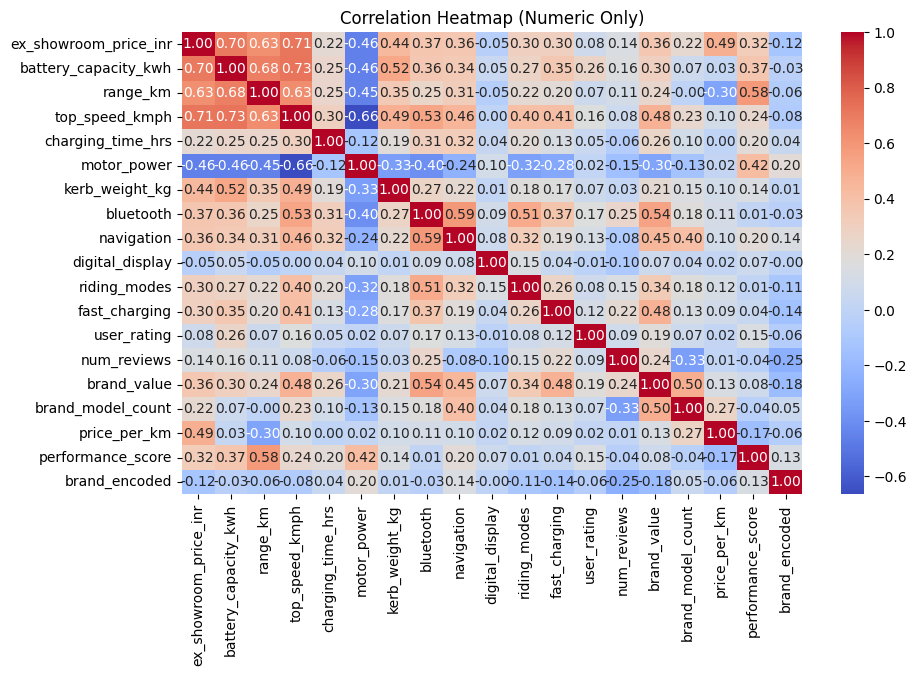

Skipping scooter_name (too many categories)
Skipping brand (too many categories)
Skipping variant (too many categories)
Skipping url (too many categories)

 Identified segment as a Categorical Column
Encoded as values: [1 0 2]

 Identified brand_country as a Categorical Column
Encoded as values: [0 1]


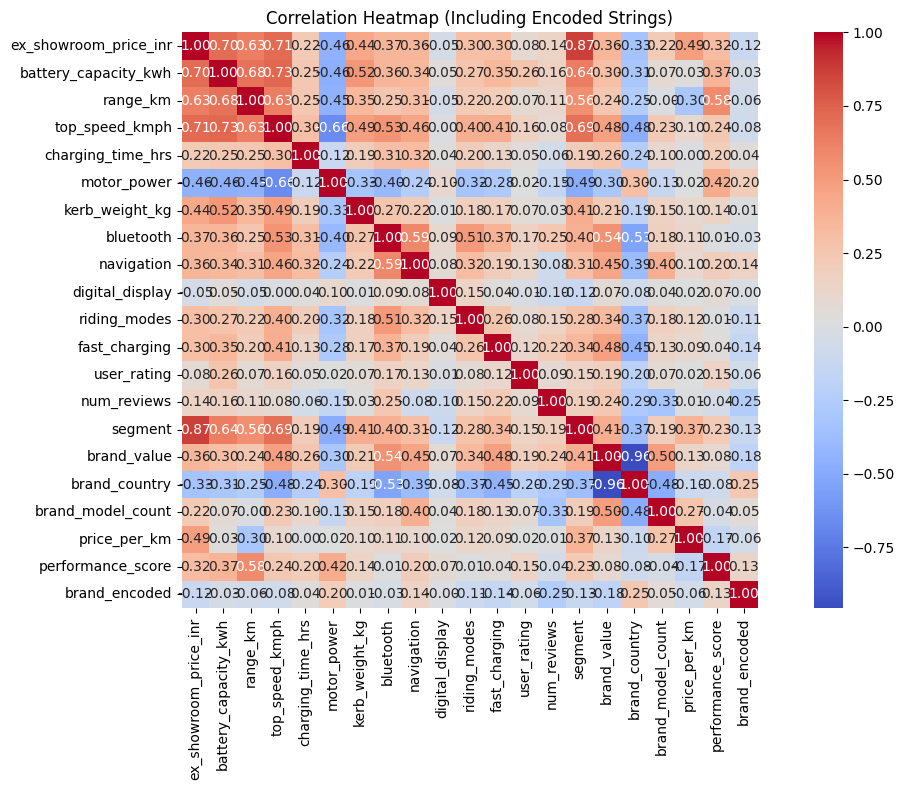


✅ EDA complete.
<class 'pandas.core.frame.DataFrame'>
Index: 251 entries, 0 to 362
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ex_showroom_price_inr  251 non-null    float64
 1   battery_capacity_kwh   251 non-null    float64
 2   range_km               251 non-null    float64
 3   top_speed_kmph         251 non-null    float64
 4   charging_time_hrs      251 non-null    float64
 5   motor_power            251 non-null    float64
 6   kerb_weight_kg         251 non-null    float64
 7   bluetooth              251 non-null    int64  
 8   navigation             251 non-null    int64  
 9   digital_display        251 non-null    int64  
 10  riding_modes           251 non-null    bool   
 11  fast_charging          251 non-null    int64  
 12  user_rating            251 non-null    float64
 13  num_reviews            251 non-null    float64
 14  segment                251 non-null    int64  

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Correlation Matrix (Numeric Columns) - initial check
print("\n🔹 Correlation Matrix (Numeric Columns):")
corr_numeric = df.corr(numeric_only=True)
display(corr_numeric)

# Heatmap of correlations with only numeric
if not corr_numeric.empty:
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr_numeric, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Heatmap (Numeric Only)")
    plt.show()


# IDENTIFY COLUMNS WHICH CAN BE CONVERTED TO CATEGORICAL VALUES AND PERFORM CO-RELATIONS

# Step 1: Make a copy to encode
df_encoded = df.copy()

# Step 2: Encode string columns
for col in df_encoded.select_dtypes(include=['object', 'string']):
    if df_encoded[col].nunique() < 20:  # Avoid high-cardinality
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        print(f"\n Identified {col} as a Categorical Column")
        print(f"Encoded as values: {df_encoded[col].unique()}")
    else:
        print(f"Skipping {col} (too many categories)")
        df_encoded.drop(columns=[col], inplace=True)

# Step 3: Correlation matrix
corr = df_encoded.corr(numeric_only=True)

# Step 4: Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (Including Encoded Strings)")
plt.tight_layout()
plt.show()

print("\n✅ EDA complete.")

df_encoded.info()


print("\n✅ Incremental EDA complete.")

In [ ]:
df = df.drop(columns=["digital_display", "user_rating", "num_reviews"], errors='ignore')

df.to_csv("cleaned_dataset.csv", index=False)